In [1]:
#IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data Import & Shape Analysis
df = pd.read_csv("cleaned_hospital_readmission.csv")
print(df.head())

    age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0  75.0                 8                72             1             18   
1  75.0                 3                34             2             13   
2  55.0                 5                45             0             18   
3  75.0                 2                36             0             12   
4  65.0                 1                42             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty       diag_1  \
0             2            0            0           General  Circulatory   
1             0            0            0             Other        Other   
2             0            0            0           General  Circulatory   
3             1            0            0           General  Circulatory   
4             0            0            0  InternalMedicine        Other   

        diag_2       diag_3 glucose_test A1Ctest change diabetes_med  \
0  Respiratory

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [9]:
df.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

In [11]:
duplicates = df.duplicated()
print ("total dulpicates",duplicates.sum())

total dulpicates 0


In [15]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [age, time_in_hospital, n_lab_procedures, n_procedures, n_medications, n_outpatient, n_inpatient, n_emergency, medical_specialty, diag_1, diag_2, diag_3, glucose_test, A1Ctest, change, diabetes_med, readmitted]
Index: []


In [23]:
# Convert age bracket to midpoint integer
df['age'] = df['age'].str.extract(r'(\d+)').astype(float) + 5


In [25]:
print(df.head())

    age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0  75.0                 8                72             1             18   
1  75.0                 3                34             2             13   
2  55.0                 5                45             0             18   
3  75.0                 2                36             0             12   
4  65.0                 1                42             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty       diag_1  \
0             2            0            0           Missing  Circulatory   
1             0            0            0             Other        Other   
2             0            0            0           Missing  Circulatory   
3             1            0            0           Missing  Circulatory   
4             0            0            0  InternalMedicine        Other   

        diag_2       diag_3 glucose_test A1Ctest change diabetes_med  \
0  Respiratory

In [27]:
# Replace 'Missing' in medical_specialty
df['medical_specialty'] = df['medical_specialty'].replace('Missing', np.nan).fillna('General')

In [29]:
print(df['medical_specialty'].value_counts())


medical_specialty
General                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64


In [31]:
print(df['medical_specialty'].isnull().sum())


0


In [33]:
print(df[['medical_specialty']].head(10))


        medical_specialty
0                 General
1                   Other
2                 General
3                 General
4        InternalMedicine
5                 General
6                 General
7                   Other
8        InternalMedicine
9  Family/GeneralPractice


In [35]:
df.replace('Missing', pd.NA, inplace=True)
df.fillna({
    'medical_specialty': 'General',
    'diag_1': 'Other',
    'diag_2': 'Other',
    'diag_3': 'Other'
}, inplace=True)


In [37]:
print(df[['age']].head(10))


    age
0  75.0
1  75.0
2  55.0
3  75.0
4  65.0
5  45.0
6  55.0
7  65.0
8  85.0
9  75.0


In [39]:
# Statistical Analysis & Validation


In [5]:
print(df.describe())


                age  time_in_hospital  n_lab_procedures  n_procedures  \
count  25000.000000       25000.00000       25000.00000  25000.000000   
mean      68.441200           4.45332          43.24076      1.352360   
std       13.156332           3.00147          19.81862      1.715179   
min       45.000000           1.00000           1.00000      0.000000   
25%       55.000000           2.00000          31.00000      0.000000   
50%       65.000000           4.00000          44.00000      1.000000   
75%       75.000000           6.00000          57.00000      2.000000   
max       95.000000          14.00000         113.00000      6.000000   

       n_medications  n_outpatient   n_inpatient   n_emergency    readmitted  \
count   25000.000000  25000.000000  25000.000000  25000.000000  25000.000000   
mean       16.252400      0.366400      0.615960      0.186600      0.470160   
std         8.060532      1.195478      1.177951      0.885873      0.499119   
min         1.000000  

In [6]:
df.to_csv("cleaned_hospital_readmission.csv", index=False)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                25000 non-null  float64
 1   time_in_hospital   25000 non-null  int64  
 2   n_lab_procedures   25000 non-null  int64  
 3   n_procedures       25000 non-null  int64  
 4   n_medications      25000 non-null  int64  
 5   n_outpatient       25000 non-null  int64  
 6   n_inpatient        25000 non-null  int64  
 7   n_emergency        25000 non-null  int64  
 8   medical_specialty  25000 non-null  object 
 9   diag_1             25000 non-null  object 
 10  diag_2             25000 non-null  object 
 11  diag_3             25000 non-null  object 
 12  glucose_test       25000 non-null  object 
 13  A1Ctest            25000 non-null  object 
 14  change             25000 non-null  object 
 15  diabetes_med       25000 non-null  object 
 16  readmitted         250

<Axes: xlabel='time_in_hospital', ylabel='n_procedures'>

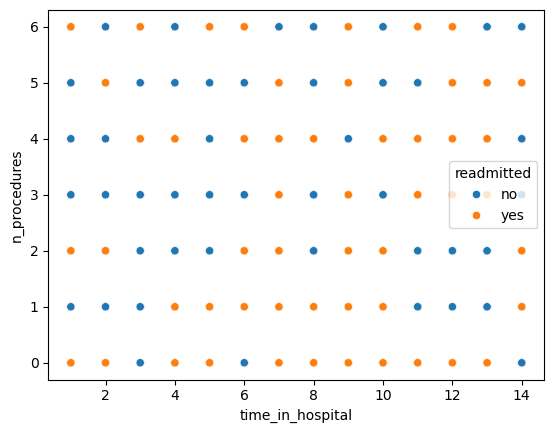

In [43]:
# Trend Analysis: Stay vs. Procedures
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='time_in_hospital', y='n_procedures', hue='readmitted', data=df)


In [47]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()


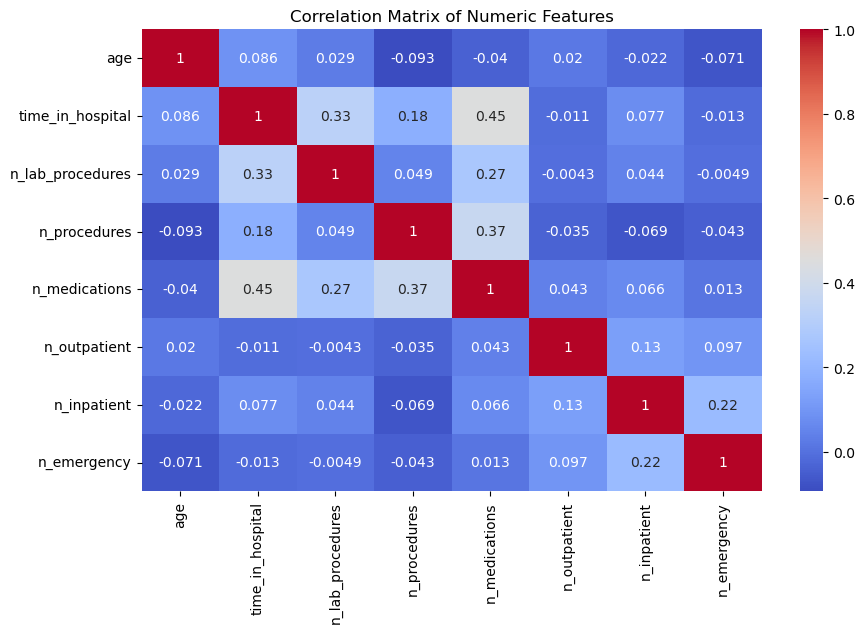

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()


In [51]:
df['readmitted'] = df['readmitted'].map({'no': 0, 'yes': 1})

In [53]:
print(df.head())

    age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0  75.0                 8                72             1             18   
1  75.0                 3                34             2             13   
2  55.0                 5                45             0             18   
3  75.0                 2                36             0             12   
4  65.0                 1                42             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty       diag_1  \
0             2            0            0           General  Circulatory   
1             0            0            0             Other        Other   
2             0            0            0           General  Circulatory   
3             1            0            0           General  Circulatory   
4             0            0            0  InternalMedicine        Other   

        diag_2       diag_3 glucose_test A1Ctest change diabetes_med  \
0  Respiratory

<Axes: xlabel='medical_specialty'>

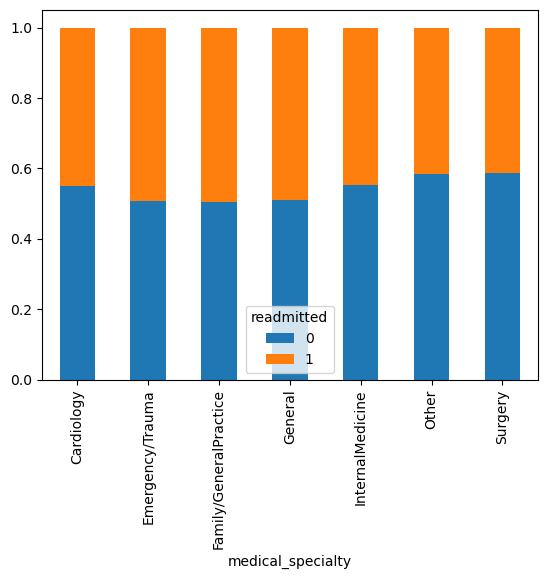

In [61]:
df.groupby('medical_specialty')['readmitted'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)


<Axes: xlabel='readmitted', ylabel='total_visits'>

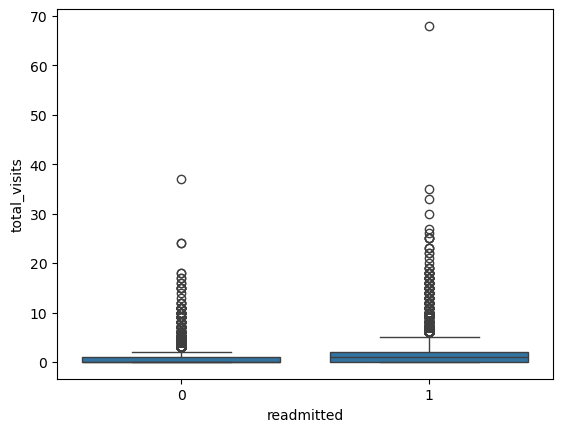

In [57]:
# Impact of total visits on readmission
df['total_visits'] = df['n_outpatient'] + df['n_inpatient'] + df['n_emergency']
sns.boxplot(x='readmitted', y='total_visits', data=df)


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['time_in_hospital', 'n_medications', 'total_visits']]
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model Accuracy:", model.score(X_test, y_test))


Model Accuracy: 0.6042


In [67]:
df.to_csv('hospital_readmissions_cleaned.csv', index=False)


In [21]:
# model_train.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# Load data
df = pd.read_csv('C:\\Users\\Dhusyath\\Downloads\\PROJECTS_DA\\PROJECTS_DA\\hospital_readmissions_cleaned.csv')

# Encode categorical columns
categorical_cols = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Features and target
X = df.drop(columns=['readmitted'])
y = df['readmitted']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "readmission_model.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")


['feature_names.pkl']

In [20]:
df=pd.read_csv('C:\\Users\\Dhusyath\\Downloads\\PROJECTS_DA\\PROJECTS_DA\\hospital_readmissions_cleaned.csv')
df.head()



,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted,total_visits
0,75.0,8,72,1,18,2,0,0,General,Circulatory,Respiratory,Other,no,no,no,yes,0,2
1,75.0,3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,0,0
2,55.0,5,45,0,18,0,0,0,General,Circulatory,Circulatory,Circulatory,no,no,yes,yes,1,0
3,75.0,2,36,0,12,1,0,0,General,Circulatory,Other,Diabetes,no,no,yes,yes,1,1
4,65.0,1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,0,0
